In [1]:
%load_ext autoreload
%autoreload 2

# The xBD-S12 dataset - Quick Exploration

In [44]:
import matplotlib.pyplot as plt
from src.data.metadata import load_metadata
from src.constants import COLORS_ORIGINAL, CLASSES_ORIGINAL

## Visualization

## Metadata
The dataset is based on a single `.geojson` file containing the metadata for all the tiles.

In [7]:
gdf = load_metadata()
print(gdf.shape)
gdf.head()

(10315, 34)


,disaster,disaster_type,peril,xbd_tier,event_split,best_utm,N_intact,N_minor,N_major,N_destroyed,N_unclassified,N_total,xbd_date_pre,xbd_date_post,xbd_catalog_id_pre,xbd_catalog_id_post,xbd_sensor_pre,xbd_sensor_post,xbd_perc_nan_pre,xbd_perc_nan_post,s2_mgrs_tile,s2_date_pre,s2_date_post,s2_cs_pre,s2_cs_post,s1_date_pre,s1_date_post,s1_orbit_pre,s1_orbit_post,s1_direction_pre,s1_direction_post,s1_ids_pre,s1_ids_post,geometry
xbd_uid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
guatemala-volcano_00000000,guatemala-volcano,volcano,volcano,train,test,EPSG:32615,10,0,0,0,0,10,2018-02-05,2018-06-22,10400100377A9B00,104001003E575F00,WORLDVIEW03_VNIR,WORLDVIEW03_VNIR,0.130739,0.0,15PYR,2018-02-14,2018-06-29,0.9830081588697369,0.832290,2018-02-06,2018-06-24,26,26,DESCENDING,DESCENDING,S1B_IW_GRDH_1SDV_20180206T115329_20180206T1153...,S1A_IW_GRDH_1SDV_20180624T115419_20180624T1154...,"POLYGON ((-90.8132 14.39158, -90.81325 14.3870..."
guatemala-volcano_00000001,guatemala-volcano,volcano,volcano,train,test,EPSG:32615,0,4,0,0,0,4,2018-02-05,2018-06-22,10400100377A9B00,104001003E575F00,WORLDVIEW03_VNIR,WORLDVIEW03_VNIR,0.105810,0.0,15PYR,2018-02-14,2018-07-04,0.9783553427338454,0.858505,2018-02-06,2018-06-24,26,26,DESCENDING,DESCENDING,S1B_IW_GRDH_1SDV_20180206T115329_20180206T1153...,S1A_IW_GRDH_1SDV_20180624T115419_20180624T1154...,"POLYGON ((-90.81316 14.39612, -90.8132 14.3915..."
guatemala-volcano_00000002,guatemala-volcano,volcano,volcano,train,test,EPSG:32615,0,0,0,1,0,1,2018-02-05,2018-06-22,10400100377A9B00,104001003E575F00,WORLDVIEW03_VNIR,WORLDVIEW03_VNIR,0.000000,0.0,15PYS,2018-02-14,2018-07-04,0.9981983836520222,0.884884,2018-02-06,2018-06-24,26,26,DESCENDING,DESCENDING,S1B_IW_GRDH_1SDV_20180206T115329_20180206T1153...,S1A_IW_GRDH_1SDV_20180624T115419_20180624T1154...,"POLYGON ((-90.83303 14.42975, -90.83308 14.425..."
guatemala-volcano_00000003,guatemala-volcano,volcano,volcano,test,test,EPSG:32615,0,2,0,1,0,3,2018-02-05,2018-06-22,10400100377A9B00,104001003E575F00,WORLDVIEW03_VNIR,WORLDVIEW03_VNIR,0.000000,0.0,15PYS,2018-02-14,2018-07-04,0.9921593428483853,0.893014,2018-02-06,2018-06-24,26,26,DESCENDING,DESCENDING,S1B_IW_GRDH_1SDV_20180206T115329_20180206T1153...,S1A_IW_GRDH_1SDV_20180624T115419_20180624T1154...,"POLYGON ((-90.83294 14.43882, -90.83299 14.434..."
guatemala-volcano_00000004,guatemala-volcano,volcano,volcano,hold,test,EPSG:32615,2,6,8,4,0,20,2018-02-05,2018-06-22,10400100377A9B00,104001003E575F00,WORLDVIEW03_VNIR,WORLDVIEW03_VNIR,0.000000,0.0,15PYS,2018-02-14,2018-07-04,0.9911691457702273,0.888752,2018-02-06,2018-06-24,26,26,DESCENDING,DESCENDING,S1B_IW_GRDH_1SDV_20180206T115329_20180206T1153...,S1A_IW_GRDH_1SDV_20180624T115419_20180624T1154...,"POLYGON ((-90.82838 14.4297, -90.82842 14.4251..."


### Number of image pairs
Each image pair (pre- and post-disaster) is referred by a unique ID (`xbd_uid`). The dataset contains 10,315 pairs.

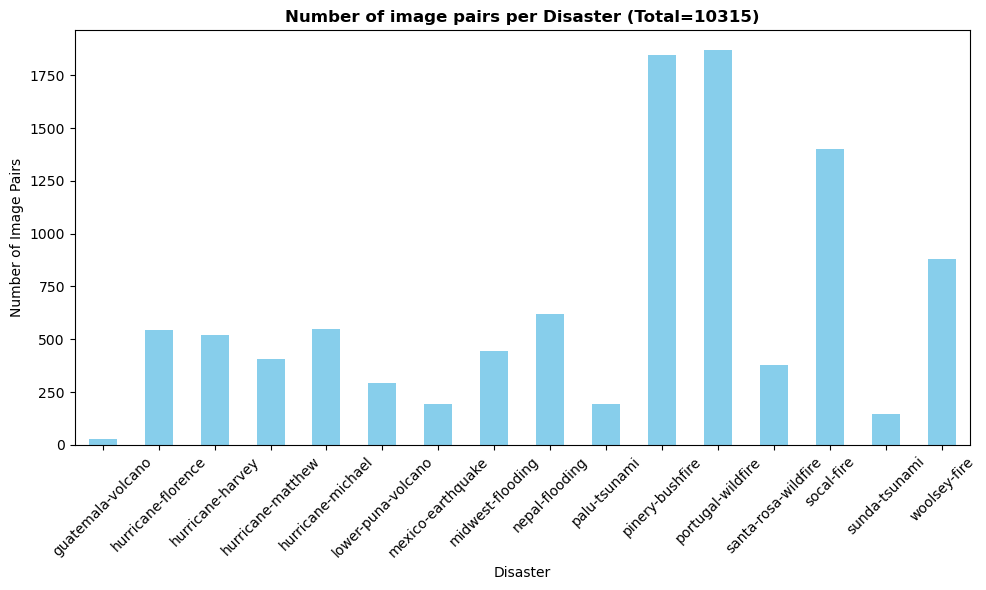

In [69]:
total_image_pairs_per_disaster = gdf.groupby("disaster").size()
fig, ax = plt.subplots(figsize=(10, 6))
total_image_pairs_per_disaster.plot(kind="bar", ax=ax, color="skyblue")
ax.set_title(f"Number of image pairs per Disaster (Total={total_image_pairs_per_disaster.sum()})", fontweight='bold')
ax.set_xlabel("Disaster")
ax.set_ylabel("Number of Image Pairs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Building Instances
We keep track of how many building instances there are per tile and per damage class.

#### Number of building instances per damage class and per disaster

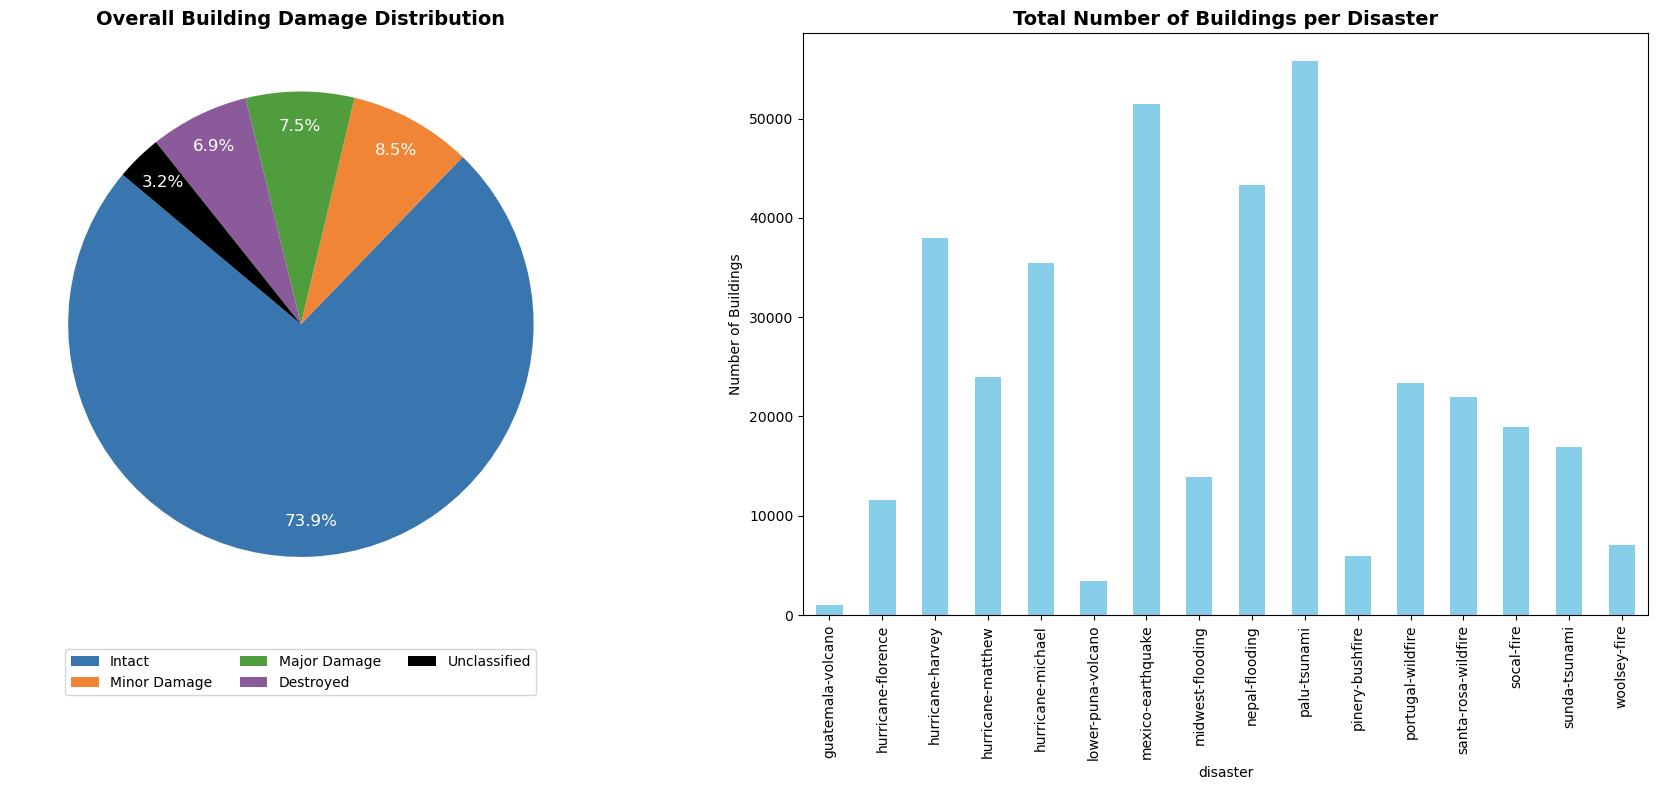

In [61]:
columns_count = ['N_intact', 'N_minor', 'N_major', 'N_destroyed', 'N_unclassified']
total_per_class = gdf[columns_count].sum()
total_per_disaster = gdf.groupby('disaster')['N_total'].sum()

labels = ['Intact', 'Minor Damage', 'Major Damage', 'Destroyed', 'Unclassified']
classes_to_int = {name: idx for idx, name in CLASSES_ORIGINAL.items()}
colors = [COLORS_ORIGINAL[classes_to_int[l]] for l in labels]


# Create the figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: Global distribution (Pie Chart) (text in white)
axes[0].pie(total_per_class, labels=None, colors=colors, startangle=140, autopct='%1.1f%%', pctdistance=0.85, textprops={'color': 'white', 'fontsize': 12})
axes[0].set_title(f'Overall Building Damage Distribution', fontsize=14, fontweight='bold')
axes[0].legend(labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.15))

# Subplot 2: Total building count per disaster (Bar Chart)
total_per_disaster.plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Total Number of Buildings per Disaster', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Buildings')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

#### Number of building instances per damage class per disaster

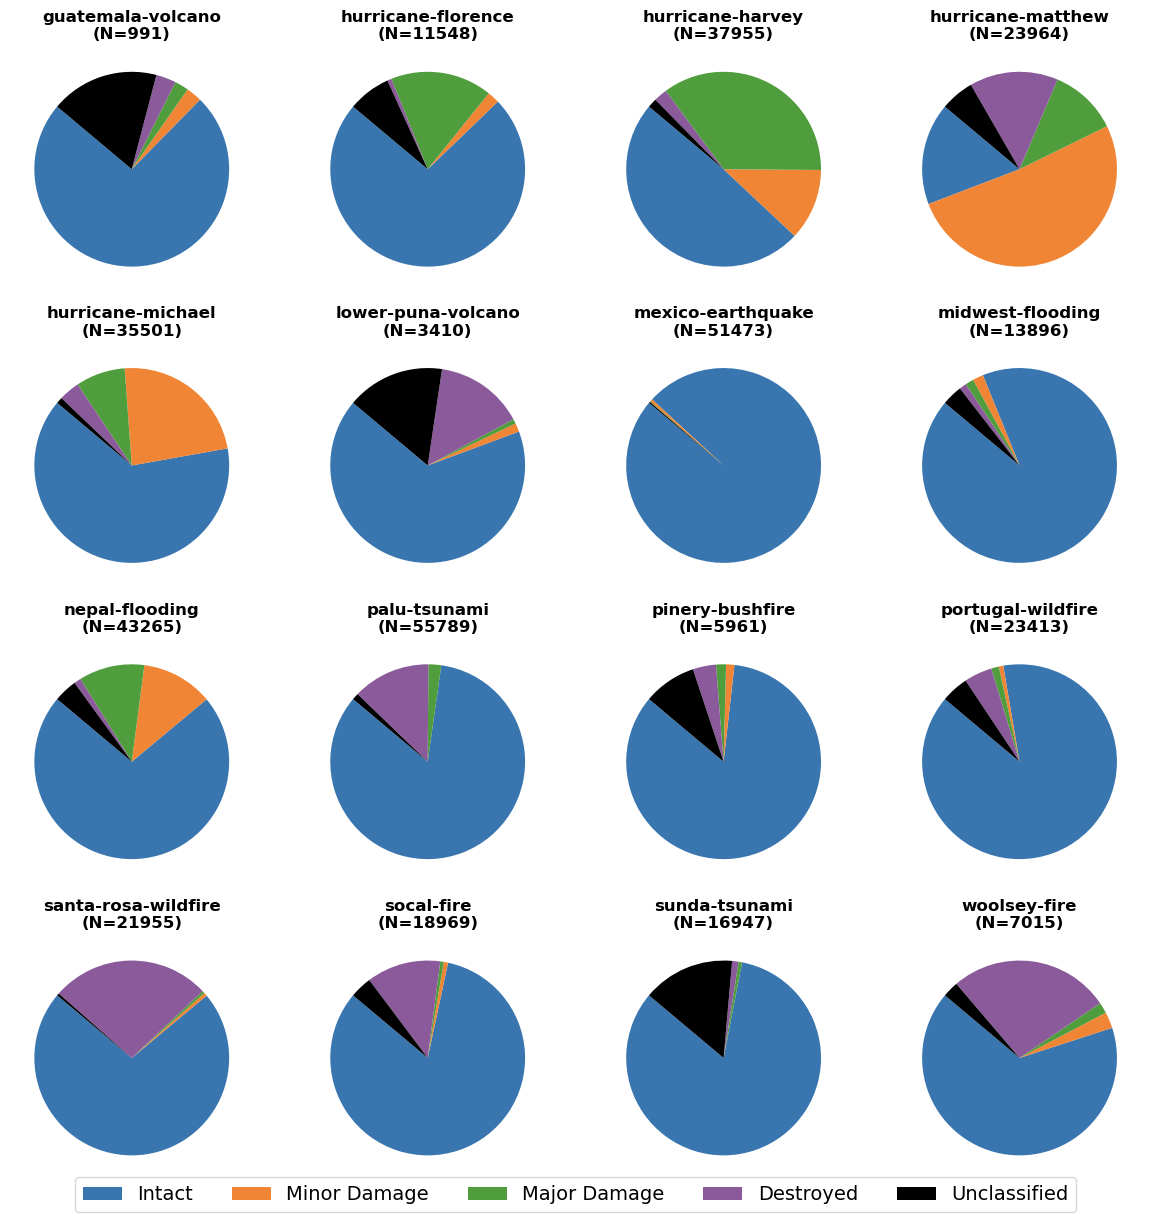

In [ ]:
columns_count = ['N_intact', 'N_minor', 'N_major', 'N_destroyed', 'N_unclassified']
total_per_class_per_disaster = gdf.groupby('disaster')[columns_count].sum()

labels = ['Intact', 'Minor Damage', 'Major Damage', 'Destroyed', 'Unclassified']
classes_to_int = {name: idx for idx, name in CLASSES_ORIGINAL.items()}
colors = [COLORS_ORIGINAL[classes_to_int[l]] for l in labels]

# Create a 4x4 grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

# Plot each disaster as a pie chart
for i, (idx, row) in enumerate(total_per_class_per_disaster.iterrows()):
    if i < 16:
        axes[i].pie(row[columns_count], colors=colors, startangle=140)
        axes[i].set_title(f"{row.name}\n(N={row.sum()})", fontsize=12, fontweight='bold')
    else:
        axes[i].axis('off')

# Add a common legend for the entire figure
fig.legend(labels, loc='center', ncol=5, fontsize=14, bbox_to_anchor=(0.5, 0))
plt.tight_layout()
plt.show()